In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
'''
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')



In [2]:
import os
import pandas as pd
import numpy as np

from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import json

import matplotlib.pyplot as plt
import seaborn as sns
import torch

from PIL import Image

from torch import nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from torchvision import transforms
from transformers import AutoImageProcessor
from transformers import ViTForImageClassification
from sklearn.utils.class_weight import compute_class_weight
from torchvision.transforms import v2

import timm
import torch
import torch.nn as nn
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights


from tqdm.auto import tqdm


import copy
import time
from torch.utils.data import DataLoader


from PIL import Image
from torch.utils.data import Dataset
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader


SEED = 42

# No Kaggle, o caminho base sempre começa com /kaggle/input/
base_dir = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'

# Listando as pastas disponíveis no dataset para conferir os nomes
print("Conteúdo do dataset:", os.listdir(base_dir))

# Carregando o arquivo CSV de metadados
metadata_path = os.path.join(base_dir, 'HAM10000_metadata.csv')
df = pd.read_csv(metadata_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nTotal de imagens registradas: {len(df)}")
df.head()

Conteúdo do dataset: ['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']

Total de imagens registradas: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# pre-processing

In [3]:
label_map = {
    'nv':    0,
    'mel':   1,
    'bkl':   2,
    'bcc':   3,
    'akiec': 4,
    'vasc':  5,
    'df':    6
}

df['label'] = df['dx'].map(label_map)

print("Mapeamento de classes:")
for k, v in label_map.items():
    print(f"  {v} → {k}")

Mapeamento de classes:
  0 → nv
  1 → mel
  2 → bkl
  3 → bcc
  4 → akiec
  5 → vasc
  6 → df


In [4]:
imageid_path = {}
for dirname, _, filenames in os.walk(base_dir+'/ham10000_images_part_1'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        # print(filename[:-4])
        imageid_path[filename[:-4]] = os.path.join(dirname, filename)
        
for dirname, _, filenames in os.walk(base_dir+'/ham10000_images_part_2'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        # print(filename[:-4])
        imageid_path[filename[:-4]] = os.path.join(dirname, filename)


df['filepath'] = df['image_id'].map(imageid_path.get)

In [ ]:
missing = df[~df['filepath'].apply(lambda x: Path(x).exists())]
print(f"Imagens faltando: {len(missing)}")

In [ ]:
# Primeiro split: separa teste (15%) do restante (85%)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
remaining_idx, test_idx = next(gss_test.split(df, df['label'], groups=df['lesion_id']))

df_remaining = df.iloc[remaining_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

# Segundo split: separa validação (15% do restante) de treino
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss_val.split(df_remaining, df_remaining['label'], groups=df_remaining['lesion_id']))

df_train = df_remaining.iloc[train_idx].reset_index(drop=True)
df_val = df_remaining.iloc[val_idx].reset_index(drop=True)

print(f"Treino:    {len(df_train)} imagens ({len(df_train)/len(df)*100:.1f}%)")
print(f"Validação: {len(df_val)} imagens ({len(df_val)/len(df)*100:.1f}%)")
print(f"Teste:     {len(df_test)} imagens ({len(df_test)/len(df)*100:.1f}%)")

In [ ]:
train_lesions = set(df_train['lesion_id'])
val_lesions = set(df_val['lesion_id'])
test_lesions = set(df_test['lesion_id'])

print(f"Vazamento treino/val:   {len(train_lesions & val_lesions)} lesion_ids em comum")
print(f"Vazamento treino/teste: {len(train_lesions & test_lesions)} lesion_ids em comum")
print(f"Vazamento val/teste:    {len(val_lesions & test_lesions)} lesion_ids em comum")

# Data augum

In [ ]:
print(df_train['dx'].value_counts())


df_transform = df_train.query("dx != 'nv'")

print(len(df_train), len(df_transform), '\n')
print(df_transform['dx'].value_counts())

# df_transform



In [ ]:
OUTPUT_DIR = "/kaggle/working/augmented_data/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

new_data = df_transform.copy()
new_metadata_rows = []

NUM_AUGMENTATIONS_PER_IMAGE = 3


variations = [
    v2.Compose([
        v2.Resize((224, 224)),
        v2.RandomHorizontalFlip(p=1.0),
        v2.ColorJitter(brightness=(1.1, 1.1), contrast=(1.1, 1.1))
    ]),
    v2.Compose([
        v2.Resize((224, 224)),
        v2.RandomVerticalFlip(p=1.0),
        v2.ColorJitter(brightness=(1.1, 1.1), contrast=(1.1, 1.1))
    ]),
    v2.Compose([
        v2.Resize((224, 224)),
        v2.RandomRotation(degrees=(90, 90)),
        v2.ColorJitter(brightness=(1.1, 1.1), contrast=(1.1, 1.1))
    ])
]

for idx, row in tqdm(df_transform.iterrows(), total=len(df_transform)):
    image_id = row['image_id']
    
    img_path = row['filepath']

    if os.path.exists(img_path):
        # Abrir imagem original usando PIL
        original_img = Image.open(img_path).convert('RGB')

        base_output_path = os.path.join(OUTPUT_DIR, f"{image_id}.jpg")
        if not os.path.exists(base_output_path):#or True
            row['filepath'] = base_output_path#OUTPUT_DIR + image_id + ".jpg"
            original_img.resize((224, 224)).save(base_output_path, 'JPEG')
            new_metadata_rows.append(row) # Mantém a linha original para o novo CSV
       
        for i in range(len(variations)):
            augmented_img = variations[i](original_img)
            
            # Definir novo ID único para a imagem modificada
            new_image_id = f"{image_id}_aug_{i}"
            output_file_path = os.path.join(OUTPUT_DIR, f"{new_image_id}.jpg")
            
            if not os.path.exists(output_file_path):# or True
                # Salva fisicamente a imagem transformada no disco rígido do Kaggle
                augmented_img.save(output_file_path, 'JPEG')
                
                # Copiar os metadados originais da linha e atualizar o ID da imagem
                new_row = row.copy()
                new_row['image_id'] = new_image_id
                new_row['filepath'] = output_file_path
                new_metadata_rows.append(new_row)

In [ ]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    image_id = row['image_id']
    
    img_path = row['filepath']

    if os.path.exists(img_path):
        # Abrir imagem original usando PIL
        original_img = Image.open(img_path).convert('RGB')

        base_output_path = os.path.join(OUTPUT_DIR, f"{image_id}.jpg")
        if not os.path.exists(base_output_path):
            row['filepath'] = base_output_path#OUTPUT_DIR + image_id + ".jpg"
            original_img.resize((224, 224)).save(base_output_path, 'JPEG')
            new_metadata_rows.append(row) # Mantém a linha original para o novo CSV
       

# Salvando dataframe para outras sessoes

In [ ]:
processedData = pd.DataFrame(new_metadata_rows, columns=df_transform.keys())

print(processedData.info())

print(processedData['image_id'].nunique())

In [ ]:
processedData.to_csv('/kaggle/working/augmented_metadata.csv', index=False)
df_train = processedData.copy()

In [ ]:
df_train.to_csv('/kaggle/working/df_train.csv', index=False)
df_val.to_csv('/kaggle/working/df_val.csv', index=False)
df_test.to_csv('/kaggle/working/df_test.csv', index=False)

# carregando dataset em uma nova sessão

In [3]:

df_val = pd.read_csv("df_val.csv")
df_test = pd.read_csv("df_test.csv")

#oversampling
'''
df_train_full = pd.read_csv("df_train.csv")
n_amostras = 2400
df_only_nv = df_train_full[df_train_full["dx"] == "nv"]

df_classe_os = df_only_nv.sample(
    n=n_amostras,
    replace=True,
    random_state=42
)

df_train = pd.concat(
    [df_train_full[df_train_full["dx"] != "nv"], df_classe_os],
    ignore_index=True
)
'''
df_train = pd.read_csv("df_train.csv")

In [4]:
encoder = LabelEncoder()

df_train["label"] = encoder.fit_transform(df_train["dx"])
df_test["label"] = encoder.transform(df_test["dx"])
df_val["label"] = encoder.transform(df_val["dx"])

num_classes = len(encoder.classes_)
print(num_classes)

7


In [5]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class HAMDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.labels = self.df["label"].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(row.filepath).convert("RGB")

        image = self.transform(image)

        label = torch.tensor(row.label, dtype=torch.long)

        return image, label


# 1. Instancie os Datasets
train_dataset = HAMDataset(df_train, transform=transform)
valid_dataset = HAMDataset(df_val, transform=transform)
test_dataset  = HAMDataset(df_test, transform=transform)

# 2. Encapsule em DataLoaders para agrupar em lotes (batches)
BATCH_SIZE = 32 # Ou 16, dependendo da memória da sua GPU

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=2, 
    persistent_workers=True,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2, 
    
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=2, 
    
    pin_memory=True
)

# fine tunnig

In [6]:
class HybridModel(nn.Module):
    def __init__(self, num_classes=7, freeze_backbones=True):
        super(HybridModel, self).__init__()
        
        # 1. Backbone CNN: EfficientNet-V2-S
        self.cnn = timm.create_model(
            'tf_efficientnetv2_s.in21k_ft_in1k', 
            pretrained=True, 
            num_classes=0
        )
        num_ftrs_cnn = self.cnn.num_features  # 1280

        # 2. Backbone ViT: Swin Transformer Tiny
        self.vit = timm.create_model(
            'swin_tiny_patch4_window7_224', 
            pretrained=True, 
            num_classes=0
        )
        num_ftrs_vit = self.vit.num_features  # 768

        # Estado inicial de congelamento dos backbones
        self.set_backbones_freeze(freeze_backbones)

        # 3. Cabeça Classificadora (Classifier Head) com Feature Fusion (1280 + 768 = 2048)
        combined_features = num_ftrs_cnn + num_ftrs_vit
        
        self.classifier_head = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(p=0.4),
            nn.Linear(512, num_classes)
        )

    def set_backbones_freeze(self, freeze=True):
        """Congela ou descongela os parâmetros dos backbones (CNN e ViT)."""
        for param in self.cnn.parameters():
            param.requires_grad = not freeze
        for param in self.vit.parameters():
            param.requires_grad = not freeze

    def forward(self, x):
        feat_cnn = self.cnn(x)
        feat_vit = self.vit(x)
        
        # Concatenação das características
        combined = torch.cat((feat_cnn, feat_vit), dim=1)
        
        # Classificação final
        out = self.classifier_head(combined)
        return out

# Instanciação do modelo na GPU/CPU
new_model = HybridModel(num_classes=7, freeze_backbones=True).to(device)
print("Modelo criado com sucesso!")

model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Modelo criado com sucesso!


In [7]:
if 'class_weights' in locals() or 'class_weights' in globals():
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
else:
    criterion = nn.CrossEntropyLoss()

def get_fine_tuning_optimizer(model):
    """Retorna o otimizador AdamW configurado com Differential Learning Rates."""
    optimizer_grouped_parameters = [
        {
            'params': model.cnn.parameters(),
            'lr': 1e-5,          # Learning rate baixo para a CNN
            'weight_decay': 1e-2
        },
        {
            'params': model.vit.parameters(),
            'lr': 1e-5,          # Learning rate baixo para o ViT
            'weight_decay': 1e-2
        },
        {
            'params': model.classifier_head.parameters(),
            'lr': 3e-4,          # Learning rate normal para a cabeça
            'weight_decay': 1e-3
        }
    ]
    return torch.optim.AdamW(optimizer_grouped_parameters)

# Otimizador inicial apenas para a fase de Warmup (cabeça de classificação)
optimizer = torch.optim.AdamW(new_model.classifier_head.parameters(), lr=3e-4, weight_decay=1e-3)

In [ ]:

# Configuração de Épocas
num_epochs_warmup = 3    # Épocas com backbones congelados
num_epochs_finetune = 12 # Épocas de fine-tuning completo
total_epochs = num_epochs_warmup + num_epochs_finetune

best_model_wts = copy.deepcopy(new_model.state_dict())
best_acc = 0.0

start_time = time.time()

# Barra de progresso para as épocas
for epoch in range(total_epochs):
    print(f"\nÉpoca {epoch + 1}/{total_epochs}")
    print("=" * 35)

    # TRANSIÇÃO: Ativação do Fine-Tuning ao fim do Warmup
    if epoch == num_epochs_warmup:
        print("\n>>> [INFO] Descongelando Backbones e iniciando Fine-Tuning Diferencial... <<<\n")
        new_model.set_backbones_freeze(freeze=False)
        optimizer = get_fine_tuning_optimizer(new_model)
        
        # Agendador Cosine Annealing para ajustar o LR durante o fine-tuning
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs_finetune)

    # Cada época tem fases de Treino e Validação
    for phase in ['train', 'val']:
        if phase == 'train':
            new_model.train()
            dataloader = train_loader
        else:
            new_model.eval()
            dataloader = valid_loader

        running_loss = 0.0
        running_corrects = 0

        # Barra de progresso para os lotes (batches) do DataLoader
        progress_bar = tqdm(
            dataloader, 
            desc=f"{phase.capitalize():<5}", 
            leave=False,
            unit="batch"
        )

        for inputs, labels in progress_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward Pass
            with torch.set_grad_enabled(phase == 'train'):
                outputs = new_model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                # Backward Pass + Otimização (Apenas no treino)
                if phase == 'train':
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(new_model.parameters(), max_norm=1.0)
                    optimizer.step()

            batch_loss = loss.item()
            running_loss += batch_loss * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            # Atualiza a métrica em tempo real na barra do tqdm
            progress_bar.set_postfix(loss=f"{batch_loss:.4f}")

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = (running_corrects.double() / len(dataloader.dataset)).item()

        print(f"[{phase.upper()}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

        # Salvar o melhor modelo com base na acurácia da validação
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(new_model.state_dict())
            torch.save(new_model.state_dict(), "best_hybrid_model.pth")
            print(f"  --> ⭐ Melhor modelo atualizado! (Val Acc: {best_acc:.4f})")

    # Atualizar o agendador de LR na fase de fine-tuning
    if epoch >= num_epochs_warmup:
        scheduler.step()

time_elapsed = time.time() - start_time
print(f"\nTreinamento concluído em {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
print(f"Melhor Acurácia de Validação: {best_acc:.4f}")

# Carregar os melhores pesos no modelo
new_model.load_state_dict(best_model_wts)


Época 1/15


Train:   0%|          | 0/225 [00:00<?, ?batch/s]

[TRAIN] Loss: 0.8018 | Acc: 0.7335


Val  :   0%|          | 0/41 [00:00<?, ?batch/s]

[VAL] Loss: 0.5866 | Acc: 0.7871
  --> ⭐ Melhor modelo atualizado! (Val Acc: 0.7871)

Época 2/15


...

Train:   0%|          | 0/225 [00:00<?, ?batch/s]

[TRAIN] Loss: 0.2091 | Acc: 0.9270


Val  :   0%|          | 0/41 [00:00<?, ?batch/s]

[VAL] Loss: 0.5537 | Acc: 0.8270
  --> ⭐ Melhor modelo atualizado! (Val Acc: 0.8270)

Época 6/15


Train:   0%|          | 0/225 [00:00<?, ?batch/s]


Avaliando no conjunto de Validação...


Avaliando Validação:   0%|          | 0/41 [00:00<?, ?it/s]


📊 RESULTADOS DE AVALIAÇÃO - CONJUNTO DE VALIDAÇÃO
✨ Acurácia Balanceada: 65.42%

📋 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

       akiec     0.6406    0.7736    0.7009        53
         bcc     0.6842    0.6420    0.6624        81
         bkl     0.5897    0.6815    0.6323       135
          df     0.8750    0.5385    0.6667        13
         mel     0.5522    0.5736    0.5627       129
          nv     0.9244    0.9034    0.9138       880
        vasc     0.8750    0.4667    0.6087        15

    accuracy                         0.8178      1306
   macro avg     0.7345    0.6542    0.6782      1306
weighted avg     0.8256    0.8178    0.8198      1306



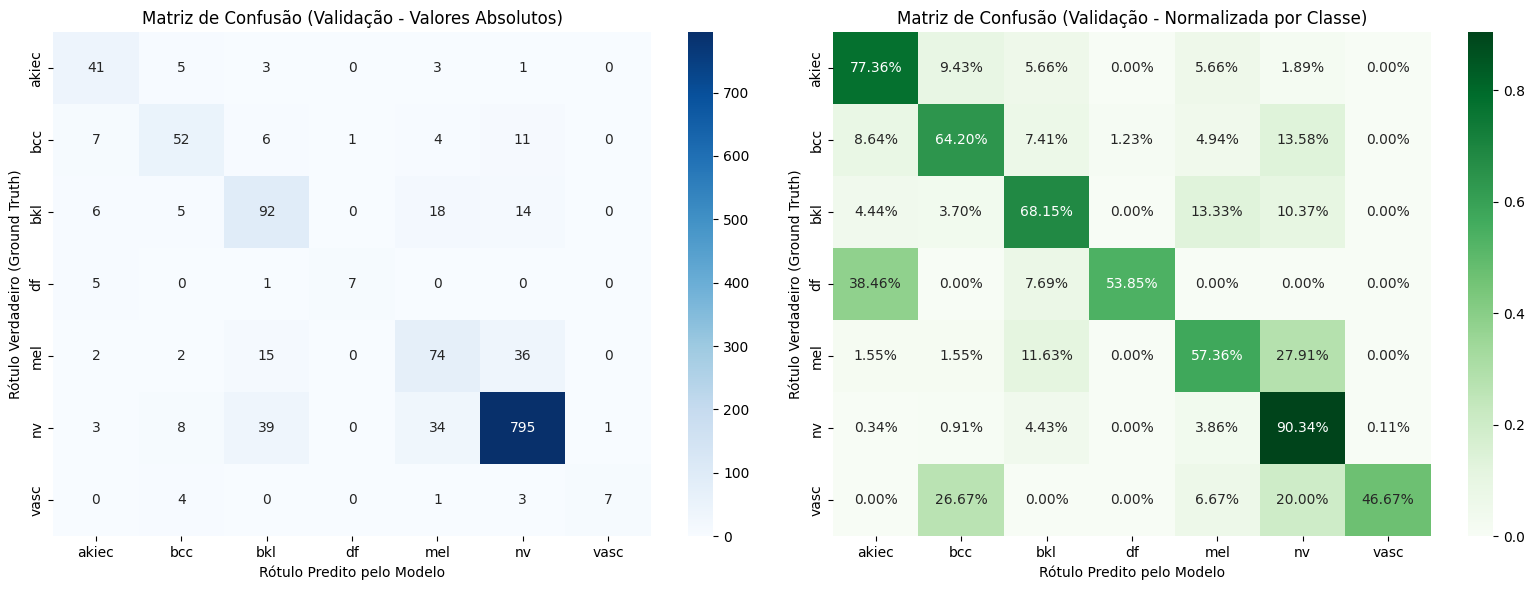

In [45]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

def evaluate_model(model, dataloader, device, class_names=CLASS_NAMES, dataset_type="Teste"):
    """
    Avalia o modelo calculando métricas detalhadas e exibindo a Matriz de Confusão.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    print(f"\nAvaliando no conjunto de {dataset_type}...")

    # Coleta das predições sem calcular gradientes
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc=f"Avaliando {dataset_type}"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # 1. Cálculo das Métricas Gerais
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    print(f"\n==================================================")
    print(f"📊 RESULTADOS DE AVALIAÇÃO - CONJUNTO DE {dataset_type.upper()}")
    print(f"==================================================")
    print(f"✨ Acurácia Balanceada: {bal_acc * 100:.2f}%\n")

    # 2. Relatório Detalhado por Classe (Precision, Recall, F1-Score)
    print("📋 Relatório de Classificação Detalhado:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    # 3. Gerando e Plotando a Matriz de Confusão
    cm = confusion_matrix(all_labels, all_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalizada por linha (Ground Truth)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfico 1: Contagem Absoluta de Amostras
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, ax=ax[0]
    )
    ax[0].set_title(f'Matriz de Confusão ({dataset_type} - Valores Absolutos)', fontsize=12)
    ax[0].set_ylabel('Rótulo Verdadeiro (Ground Truth)')
    ax[0].set_xlabel('Rótulo Predito pelo Modelo')

    # Gráfico 2: Percentual Normalizado por Classe
    sns.heatmap(
        cm_normalized, annot=True, fmt='.2%', cmap='Greens',
        xticklabels=class_names, yticklabels=class_names, ax=ax[1]
    )
    ax[1].set_title(f'Matriz de Confusão ({dataset_type} - Normalizada por Classe)', fontsize=12)
    ax[1].set_ylabel('Rótulo Verdadeiro (Ground Truth)')
    ax[1].set_xlabel('Rótulo Predito pelo Modelo')

    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUÇÃO DA AVALIAÇÃO (Rode para Validação e Teste)
# ==========================================

# 1. Avaliar na Validação
evaluate_model(new_model, valid_loader, device=device, dataset_type="Validação")

# 2. Avaliar no Teste (Descomente se tiver o test_loader definido)
# evaluate_model(new_model, test_loader, device=device, dataset_type="Teste")


Avaliando no conjunto de Teste...


Avaliando Teste:   0%|          | 0/48 [00:00<?, ?it/s]


📊 RESULTADOS DE AVALIAÇÃO - CONJUNTO DE TESTE
✨ Acurácia Balanceada: 64.98%

📋 Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

       akiec     0.5472    0.6042    0.5743        48
         bcc     0.6154    0.7273    0.6667        66
         bkl     0.6489    0.7093    0.6778       172
          df     0.4000    0.2000    0.2667        10
         mel     0.5571    0.6290    0.5909       186
          nv     0.9307    0.8858    0.9077      1016
        vasc     0.8846    0.7931    0.8364        29

    accuracy                         0.8127      1527
   macro avg     0.6549    0.6498    0.6458      1527
weighted avg     0.8234    0.8127    0.8168      1527



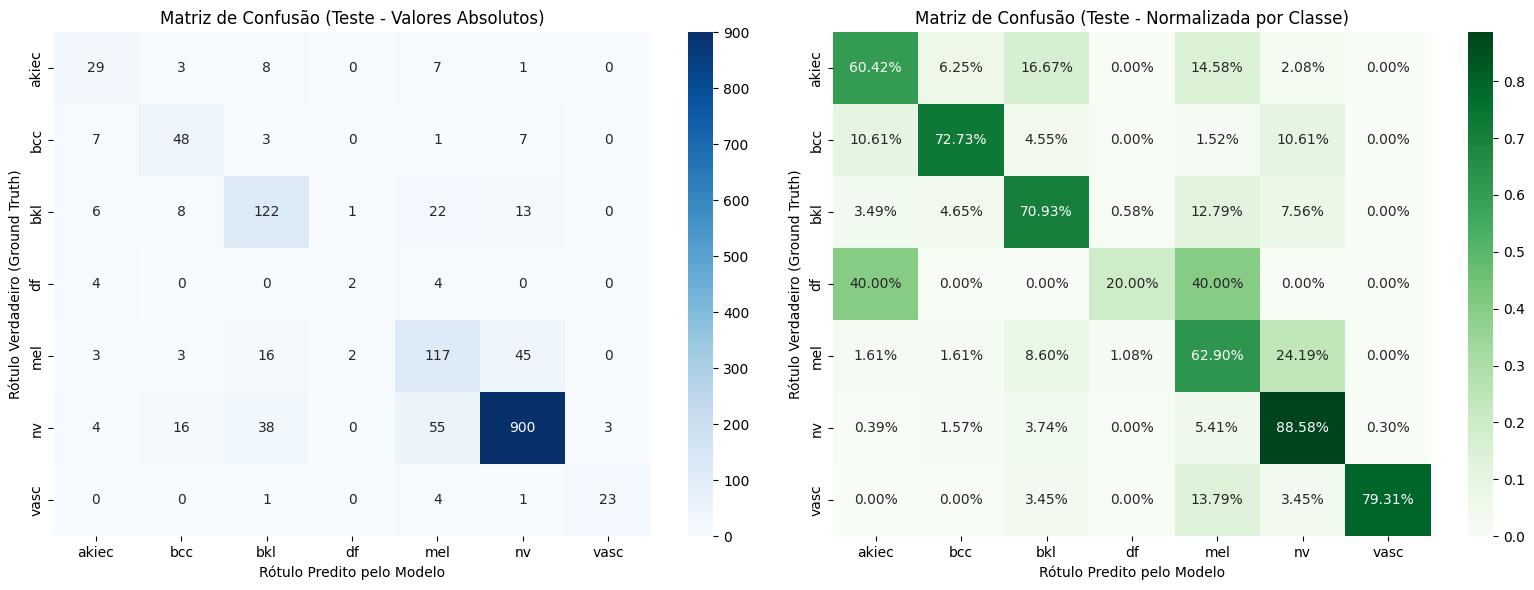

In [46]:
evaluate_model(new_model, test_loader, device=device, dataset_type="Teste")